# l=1 exposure comparison: 7-27-26 vs 8-10-26

The `8-10-26` run re-took the `29_n15 · Optimal · 40mm-65mm · l=1` focusing scan at **lower
exposure**. It is otherwise a matched pair with the `7-27-26` scan: same beam, same charge,
same 51 frames spanning z = 0 → 25 mm in 0.5 mm steps (identical `positions.csv`).

This notebook runs both through the **same pipeline** used in `waterfall_plot.ipynb`
(median-border background subtraction → thresholded two-pass centroid → row slice through the
centroid, recentred and cropped to ±200 px), then compares them using **two width metrics only**:

* **measured RMS** — the intensity-weighted second moment of the transverse cut (`_rms_width`),
  no fit and no model.
* **LG(ℓ=1) fit** — the beam is a doughnut, so the cut is fitted to a Laguerre-Gaussian
  $\ell=1$ diameter, giving the mode waist $w$. Its analytic 1-D RMS,
  $\tfrac12 w\sqrt{2|\ell|+1}$, puts the fit on the same axis as the measured RMS.

Sections:

1. **Waterfalls, relative brightness** — each map normalised to its own peak (compares *shape*).
2. **Waterfalls, absolute brightness** — both on one shared count scale (shows the exposure gap).
3. **Beam width, exposures overlaid** — measured RMS (points) against the LG(ℓ=1) RMS model
   (line), both scans on one axis, focus marked.
4. **LG(ℓ=1) fit** — example profile overlays at focus, plus the mode waist $w$ vs z.
5. **Clipping & on-axis intensity** — raw counts vs z and saturated-pixel count against the
   10-bit camera ceiling (1022). The high-exposure scan clips through the focus region.
6. **Centroid-drift diagnostic** — the main risk at low exposure is noisier tracking.
7. **Summary table** — focus z by each metric, widths, brightest z, saturated frames, drift.

All widths are in **pixels** — the repo defines no physical pixel scale.

> **Note on clipping:** the camera is 10-bit and pins at **1022 counts**. The `7-27-26` scan
> saturates across its focus region (up to ~190 pixels/frame), which flat-tops the peak and
> **biases the measured RMS upward and shifts the apparent focus**. The LG fit drops clipped
> samples, so where the two metrics disagree the LG curve and the clean `8-10-26` retake
> (peak ~290 cts) are the trustworthy references.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy.optimize import curve_fit


def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(f"no pyproject.toml at or above {here}")


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "focusing_images"
OUT_ROOT = REPO_ROOT / "outputs" / "waterfall_l1_exposure_compare"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

ELL = 1                       # OAM charge of this matched pair
REL = "40mm-65mm/l=1"         # the matched segment, relative to <date>/29_n15/Optimal
SCANS = {
    "7-27-26": DATA_ROOT / "7-27-26" / "29_n15" / "Optimal" / REL,
    "8-10-26": DATA_ROOT / "8-10-26" / "29_n15" / "Optimal" / REL,
}
# high-exposure = blue/circles, low-exposure = red/squares
STYLE = {
    "7-27-26": {"color": "#1f77b4", "marker": "o", "label": "overexposed"},
    "8-10-26": {"color": "#d62728", "marker": "s", "label": "not overexposed"},
}
COLOURS = {k: v["color"] for k, v in STYLE.items()}
LABELS = {k: v["label"] for k, v in STYLE.items()}   # display names for the two days

for label, d in SCANS.items():
    assert d.is_dir(), f"missing {d}"
    print(f"{label}: {d.relative_to(REPO_ROOT)}  ({len(list(d.glob('*.tif')))} tifs)")
print(f"figures -> {OUT_ROOT.relative_to(REPO_ROOT)}")

7-27-26: data\focusing_images\7-27-26\29_n15\Optimal\40mm-65mm\l=1  (51 tifs)
8-10-26: data\focusing_images\8-10-26\29_n15\Optimal\40mm-65mm\l=1  (51 tifs)
figures -> outputs\waterfall_l1_exposure_compare


## Tunables and pipeline helpers

Same constants and same functions as `waterfall_plot.ipynb`, lifted verbatim so the two
scans are processed identically. `_rms_width` is the transverse-RMS metric from
`waterfall_stitched_Full.ipynb`; `lg_rms_from_w` is that notebook's waist → RMS conversion,
so the fitted waist can be plotted against the measured RMS on one axis.

In [2]:
# --- acquisition / slicing (identical to waterfall_plot.ipynb) -------------
STEP_MM = 0.5           # stage step; only used if a positions.csv is missing
SLICE_AXIS = "x"        # cut along a sensor row; transverse axis is the column x
N_LINES_AVG = 1         # sensor lines averaged about the centroid per slice
TRACK_CENTRE_PER_FRAME = True
CENTER_TRANSVERSE = True
CROP_HALF_WIDTH = 200   # keep +/-200 px about centre

# --- centroid finding -----------------------------------------------------
BG_BORDER = 50          # px border strip for the background level
THRESH_FRAC = 0.10      # ignore pixels below this fraction of the frame max
WINDOW_RADIUS = 200     # px; refine centroid within this window
SAT_LEVEL = 1022        # 10-bit camera clip level; pixels pin here when saturated
INDEX_RE = re.compile(r"_(\d+)\.tif$", re.IGNORECASE)


def frame_index(path: Path) -> int:
    m = INDEX_RE.search(path.name)
    if m is None:
        raise ValueError(f"cannot parse a frame index from {path.name}")
    return int(m.group(1))


def frame_paths(directory: Path) -> list[Path]:
    tifs = [p for p in directory.glob("*.tif") if not p.name.startswith(".")]
    return sorted(tifs, key=frame_index)


def load_positions(directory: Path) -> tuple[list[Path], np.ndarray, bool]:
    """(frame paths, z in mm, positions_were_inferred) for one folder."""
    paths = frame_paths(directory)
    if not paths:
        raise FileNotFoundError(f"no TIFFs in {directory}")
    csv = directory / "positions.csv"
    if not csv.is_file():
        z = np.array([frame_index(p) * STEP_MM for p in paths], dtype=float)
        print(f"  ! {directory.name}: no positions.csv - inferring z = index * {STEP_MM} mm")
        return paths, z, True
    table = pd.read_csv(csv).sort_values("position_mm").reset_index(drop=True)
    present = np.array([(directory / name).is_file() for name in table["image"]])
    table = table[present].reset_index(drop=True)
    paths = [directory / name for name in table["image"]]
    return paths, table["position_mm"].to_numpy(dtype=float), False


def load_frames(paths: list[Path]) -> np.ndarray:
    first = np.asarray(Image.open(paths[0]), dtype=np.float32)
    frames = np.empty((len(paths), *first.shape), dtype=np.float32)
    frames[0] = first
    for i, path in enumerate(paths[1:], start=1):
        frames[i] = np.asarray(Image.open(path), dtype=np.float32)
    return frames


def background_level(frame: np.ndarray, border: int = BG_BORDER) -> float:
    edges = np.concatenate([
        frame[:border, :].ravel(), frame[-border:, :].ravel(),
        frame[:, :border].ravel(), frame[:, -border:].ravel(),
    ])
    return float(np.median(edges))


def _centroid(weights: np.ndarray) -> tuple[float, float]:
    total = weights.sum()
    if total <= 0:
        raise ValueError("no signal above threshold")
    rows = np.arange(weights.shape[0])[:, None]
    cols = np.arange(weights.shape[1])[None, :]
    return float((weights * rows).sum() / total), float((weights * cols).sum() / total)


def find_centroid(frame: np.ndarray) -> tuple[float, float, float]:
    signal = np.clip(frame - background_level(frame), 0, None)
    weights = np.where(signal >= THRESH_FRAC * signal.max(), signal, 0.0)
    cy, cx = _centroid(weights)
    if WINDOW_RADIUS is not None:
        r0 = max(int(round(cy)) - WINDOW_RADIUS, 0)
        c0 = max(int(round(cx)) - WINDOW_RADIUS, 0)
        window = weights[r0:r0 + 2 * WINDOW_RADIUS, c0:c0 + 2 * WINDOW_RADIUS]
        dy, dx = _centroid(window)
        cy, cx = r0 + dy, c0 + dx
    # brightness weight: bright, well-defined in-focus frames dominate the line fit
    return cy, cx, float(signal.max())


def _rms_width(profile: np.ndarray, s_px: np.ndarray) -> float:
    """Measured 1-D RMS of the cut: intensity-weighted second moment, no fit."""
    w = np.clip(profile, 0, None)
    total = w.sum()
    if total <= 0:
        return np.nan
    mean = (w * s_px).sum() / total
    return float(np.sqrt((w * (s_px - mean) ** 2).sum() / total))


def _lg1(s, amp, c, w, offset):
    """Transverse cut through an LG(p=0, l=1) doughnut: null at s=c, lobes at s=c +/- w/sqrt2."""
    u = 2.0 * (s - c) ** 2 / w ** 2
    return amp * u * np.exp(-u) + offset


def lg_rms_from_w(w, ell: int = ELL):
    """1-D RMS radius of a centred LG_{0,|ell|} diameter: (w/2) sqrt(2|ell|+1)."""
    return 0.5 * np.asarray(w, float) * np.sqrt(2 * abs(ell) + 1)


def _unclipped(profile: np.ndarray, s_px: np.ndarray, clip_sub: float | None):
    """(s, y>=0) with samples at/above the clip level dropped, so saturated pixels don't bias fits."""
    y = np.clip(profile, 0, None).astype(float)
    keep = np.ones_like(y, dtype=bool) if clip_sub is None else (profile < clip_sub - 1.0)
    return s_px[keep], y[keep]


def lg1_fit(profile: np.ndarray, s_px: np.ndarray, clip_sub: float | None = None):
    """Fit the LG(l=1) cut; returns popt=[amp,c,w,offset] or None. Clipped samples dropped."""
    ss, yy = _unclipped(profile, s_px, clip_sub)
    if yy.size < 6 or yy.max() <= 0:
        return None
    s_peak = float(abs(ss[np.argmax(yy)]))          # a lobe sits near +/- w/sqrt2
    p0 = [yy.max() * np.e, 0.0, max(s_peak * np.sqrt(2.0), 2.0), 0.0]
    try:
        popt, _ = curve_fit(
            _lg1, ss, yy, p0=p0,
            bounds=([0.0, -50.0, 0.5, -np.inf], [np.inf, 50.0, 500.0, np.inf]),
            maxfev=10000,
        )
    except Exception:
        return None
    return popt


def lg1_width(profile, s_px, clip_sub=None) -> float:
    """LG(l=1) mode waist w (px); nan if the fit fails. Ring radius = w/sqrt(2)."""
    p = lg1_fit(profile, s_px, clip_sub)
    return abs(float(p[2])) if p is not None else np.nan

## Process both scans

`process_scan` mirrors `process_dataset`, but keeps the waterfall in **raw background-subtracted
counts** (not yet normalised) plus its peak, so the same object can drive both the relative
(per-map peak) and absolute (shared peak) figures. `frame_max_raw` is the pre-processing
per-frame maximum, for the saturation check.

In [3]:
@dataclass
class Scan:
    label: str
    waterfall_raw: np.ndarray   # (n_z, n_s) background-subtracted, cropped, NOT normalised
    raw_peak: float             # max of waterfall_raw
    s_px: np.ndarray            # (n_s,) transverse coordinate about the centroid
    z_mm: np.ndarray            # (n_z,)
    width_px: np.ndarray        # (n_z,) measured 1-D RMS width
    lg_w_px: np.ndarray         # (n_z,) LG(l=1) mode waist w, clipped samples masked out
    clip_sub: float             # clip level in the background-subtracted map
    onaxis: np.ndarray          # (n_z,) central-column value, raw counts
    frame_max_raw: np.ndarray   # (n_z,) raw per-frame max (saturation check)
    n_saturated: np.ndarray     # (n_z,) count of pixels pinned at the clip level per frame
    centroid_y: np.ndarray
    centroid_x: np.ndarray
    inferred_positions: bool

    @property
    def lg_rms_px(self) -> np.ndarray:
        """The fitted waist expressed as a 1-D RMS, comparable with width_px."""
        return lg_rms_from_w(self.lg_w_px)

    @property
    def focus_z(self) -> float:
        return float(self.z_mm[np.nanargmin(self.width_px)])

    @property
    def min_width(self) -> float:
        return float(np.nanmin(self.width_px))

    @property
    def focus_z_lg(self) -> float:
        return float(self.z_mm[np.nanargmin(self.lg_w_px)])

    @property
    def min_lg_w(self) -> float:
        return float(np.nanmin(self.lg_w_px))

    @property
    def min_lg_rms(self) -> float:
        return float(lg_rms_from_w(self.min_lg_w))

    @property
    def brightest_z(self) -> float:
        return float(self.z_mm[self.waterfall_raw.max(axis=1).argmax()])


def process_scan(label: str, directory: Path, axis: str = SLICE_AXIS) -> Scan:
    paths, z_mm, inferred = load_positions(directory)
    frames = load_frames(paths)
    frame_max_raw = frames.reshape(frames.shape[0], -1).max(axis=1)
    n_saturated = (frames >= SAT_LEVEL).reshape(frames.shape[0], -1).sum(axis=1)

    centroids = np.array([find_centroid(f) for f in frames])
    centroid_y_raw, centroid_x_raw, centroid_w = centroids[:, 0], centroids[:, 1], centroids[:, 2]
    # Replace the wobbling per-frame centroid with a straight line in z:
    # centroid(z) = slope*z + offset, brightness-weighted.  This is a single
    # full-span scan (one section), so it gets its own slope and offset.
    from centroid_lines import fit_centroid_lines
    _lines, _ = fit_centroid_lines({"_": dict(z=z_mm, cy=centroid_y_raw, cx=centroid_x_raw, w=centroid_w)})
    centroid_y, centroid_x = _lines["_"]

    if axis == "x":
        cuts, centre_along, centre_across = frames, centroid_y, centroid_x
    else:
        cuts, centre_along, centre_across = frames.transpose(0, 2, 1), centroid_x, centroid_y
    n_lines, length = cuts.shape[1], cuts.shape[2]

    half = N_LINES_AVG // 2
    fixed_line = int(round(centre_along.mean()))
    background = float(np.median([background_level(f) for f in frames]))

    slices = []
    for plane, c_along, c_across in zip(cuts, centre_along, centre_across):
        line = int(round(c_along)) if TRACK_CENTRE_PER_FRAME else fixed_line
        lo = int(np.clip(line - half, 0, n_lines - N_LINES_AVG))
        cut = plane[lo:lo + N_LINES_AVG].mean(axis=0)
        if CENTER_TRANSVERSE:
            cut = np.roll(cut, length // 2 - int(round(c_across)))
        slices.append(cut)

    waterfall = np.clip(np.stack(slices) - background, 0, None)  # raw counts, bg-subtracted
    del cuts, frames

    s_px = np.arange(length) - (length // 2 if CENTER_TRANSVERSE else 0)
    if CROP_HALF_WIDTH is not None:
        keep = np.abs(s_px) <= CROP_HALF_WIDTH
        waterfall, s_px = waterfall[:, keep], s_px[keep]

    peak = float(waterfall.max())
    if peak <= 0:
        raise ValueError("nothing above background in any slice")

    width_px = np.array([_rms_width(row, s_px) for row in waterfall])
    clip_sub = SAT_LEVEL - background  # clip level in the background-subtracted map
    lg_w_px = np.array([lg1_width(row, s_px, clip_sub) for row in waterfall])
    centre_idx = int(np.argmin(np.abs(s_px)))
    onaxis = waterfall[:, centre_idx].astype(float)

    return Scan(
        label=label, waterfall_raw=waterfall, raw_peak=peak, s_px=s_px, z_mm=z_mm,
        width_px=width_px, lg_w_px=lg_w_px, clip_sub=clip_sub,
        onaxis=onaxis, frame_max_raw=frame_max_raw, n_saturated=n_saturated,
        centroid_y=centroid_y, centroid_x=centroid_x, inferred_positions=inferred,
    )


scans = {label: process_scan(label, d) for label, d in SCANS.items()}
for s in scans.values():
    print(f"{s.label}: RMS focus {s.focus_z:4.1f} mm (min {s.min_width:5.1f} px) | "
          f"LG focus {s.focus_z_lg:4.1f} mm (w {s.min_lg_w:4.1f} px, "
          f"RMS model {s.min_lg_rms:4.1f} px, ring {s.min_lg_w / np.sqrt(2):4.1f} px) | "
          f"sat frames {(s.n_saturated > 0).sum()}")

7-27-26: RMS focus  2.0 mm (min  16.6 px) | LG focus  6.0 mm (w  7.4 px, RMS model  6.4 px, ring  5.2 px) | sat frames 20
8-10-26: RMS focus  6.0 mm (min  12.6 px) | LG focus  5.0 mm (w  7.7 px, RMS model  6.7 px, ring  5.4 px) | sat frames 0


## 1 · Waterfalls — relative brightness

Each map normalised to **its own** peak, so both use the full 0–1 colour range. This compares
the *shape* of the focusing scan independent of exposure.

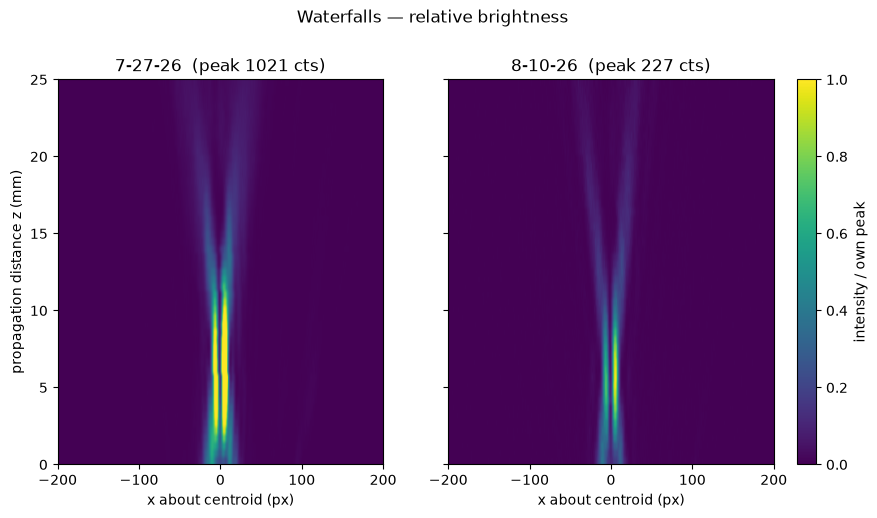

In [4]:
def draw_waterfall(ax, s: Scan, data: np.ndarray, vmax: float, title: str):
    extent = [s.s_px.min(), s.s_px.max(), s.z_mm.min(), s.z_mm.max()]
    im = ax.imshow(data, origin="lower", aspect="auto", cmap="viridis",
                   extent=extent, vmin=0, vmax=vmax)
    ax.set_xlabel(f"{SLICE_AXIS} about centroid (px)")
    ax.set_title(title)
    return im


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for ax, s in zip(axes, scans.values()):
    im = draw_waterfall(ax, s, s.waterfall_raw / s.raw_peak, 1.0,
                        f"{s.label}  (peak {s.raw_peak:.0f} cts)")
axes[0].set_ylabel("propagation distance z (mm)")
fig.colorbar(im, ax=axes, label="intensity / own peak", fraction=0.046, pad=0.03)
fig.suptitle("Waterfalls — relative brightness", y=1.02)
fig.savefig(OUT_ROOT / "waterfall_relative.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 · Waterfalls — absolute brightness

Both maps divided by the **same** peak (the brighter scan's), so the colour scale is shared.
The low-exposure scan should read visibly dimmer — this is the exposure gap made explicit.

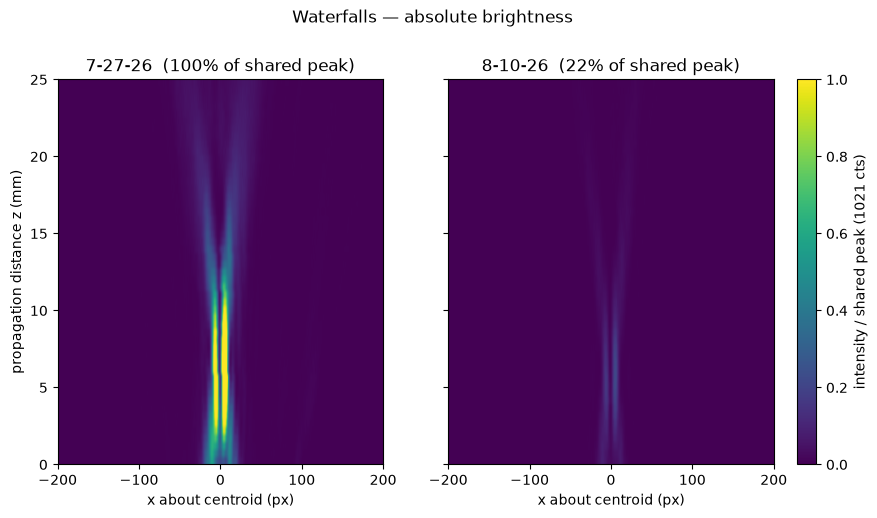

In [5]:
global_peak = max(s.raw_peak for s in scans.values())

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for ax, s in zip(axes, scans.values()):
    im = draw_waterfall(ax, s, s.waterfall_raw / global_peak, 1.0,
                        f"{s.label}  ({s.raw_peak / global_peak:.0%} of shared peak)")
axes[0].set_ylabel("propagation distance z (mm)")
fig.colorbar(im, ax=axes, label=f"intensity / shared peak ({global_peak:.0f} cts)",
             fraction=0.046, pad=0.03)
fig.suptitle("Waterfalls — absolute brightness", y=1.02)
fig.savefig(OUT_ROOT / "waterfall_absolute.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 · Beam width, exposures overlaid

The **measured RMS** beam width of each cut vs z, for the two days overlaid — `7-27-26` labelled
**overexposed** and `8-10-26` **not overexposed**. Triangles and dotted lines mark each curve's
minimum, i.e. its focus.

The measured RMS runs over the whole ±200 px window with no clip mask, so the flat-topped,
saturated peak of the overexposed scan biases its width upward and shifts the apparent focus;
the clean not-overexposed retake is the trustworthy reference.

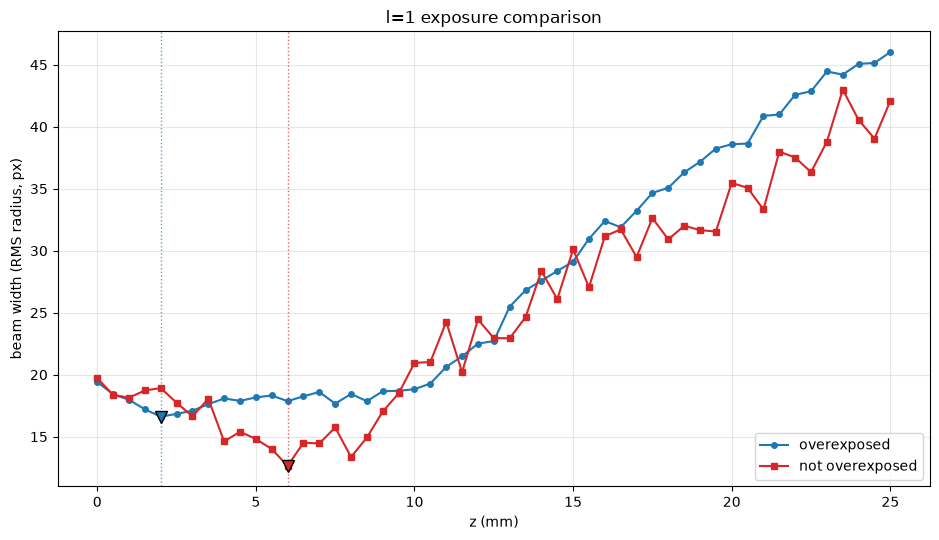

overexposed (7-27-26): measured-RMS focus  2.0 mm (min  16.6 px)
not overexposed (8-10-26): measured-RMS focus  6.0 mm (min  12.6 px)


In [6]:
def focus_index(y: np.ndarray) -> int:
    """Index of the width minimum, nan-safe."""
    return int(np.nanargmin(np.where(np.isfinite(y), y, np.inf)))


fig, ax = plt.subplots(figsize=(9.5, 5.5))
for s in scans.values():
    c, m = STYLE[s.label]["color"], STYLE[s.label]["marker"]

    ax.plot(s.z_mm, s.width_px, m + "-", ms=4, lw=1.5, color=c, label=LABELS[s.label])

    j_rms = focus_index(s.width_px)
    ax.axvline(s.z_mm[j_rms], color=c, ls=":", lw=1.0, alpha=0.7)
    ax.plot(s.z_mm[j_rms], s.width_px[j_rms], "v", color=c, ms=9, markeredgecolor="k", zorder=5)

ax.set_xlabel("z (mm)")
ax.set_ylabel("beam width (RMS radius, px)")
ax.set_title("l=1 exposure comparison")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_ROOT / "width_by_exposure.png", dpi=150, bbox_inches="tight")
plt.show()

for s in scans.values():
    print(f"{LABELS[s.label]} ({s.label}): measured-RMS focus {s.focus_z:4.1f} mm "
          f"(min {s.min_width:5.1f} px)")

## 4 · LG(ℓ=1) fit

The beam is a Laguerre-Gaussian $\text{LG}_{p=0,\ell=1}$ — a doughnut with a central **null**,
so a transverse cut through the centre is *two-lobed*. The model for the cut is

$$I(s) = A\,u\,e^{-u} + \text{offset}, \qquad u = \frac{2(s-c)^2}{w^2},$$

with zeros at the centre and lobes at $s = c \pm w/\sqrt2$. Here $w$ is the mode waist, the ring
radius is $w/\sqrt2$, and the 1-D RMS of this profile is $\tfrac12 w\sqrt{2|\ell|+1}$
(= $0.866\,w$ for $\ell=1$) — the quantity plotted against the measured RMS above.

**Example profiles at focus** (below): clipped samples (open circles) are excluded from the fit.

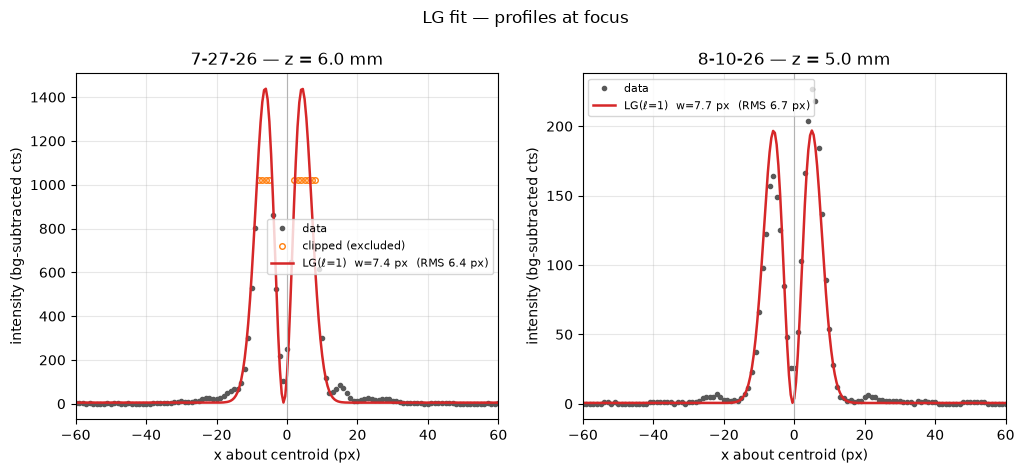

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
s_dense = np.linspace(-CROP_HALF_WIDTH, CROP_HALF_WIDTH, 801)
for ax, s in zip(axes, scans.values()):
    zi = int(np.nanargmin(s.lg_w_px))            # this scan's LG focus frame
    profile = s.waterfall_raw[zi]
    clipped = profile >= s.clip_sub - 1.0
    ax.plot(s.s_px[~clipped], profile[~clipped], "o", ms=3, color="0.35", label="data")
    if clipped.any():
        ax.plot(s.s_px[clipped], profile[clipped], "o", ms=4, mfc="none",
                mec="tab:orange", label="clipped (excluded)")
    pl = lg1_fit(profile, s.s_px, s.clip_sub)
    if pl is not None:
        w = abs(pl[2])
        ax.plot(s_dense, _lg1(s_dense, *pl), "-", color="tab:red", lw=1.8,
                label=f"LG(ℓ=1)  w={w:.1f} px  (RMS {lg_rms_from_w(w):.1f} px)")
    ax.axvline(0, color="0.7", lw=0.8)
    ax.set_title(f"{s.label} — z = {s.z_mm[zi]:.1f} mm")
    ax.set_xlabel(f"{SLICE_AXIS} about centroid (px)")
    ax.set_ylabel("intensity (bg-subtracted cts)")
    ax.set_xlim(-60, 60); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("LG fit — profiles at focus", y=1.02)
fig.savefig(OUT_ROOT / "profile_fits_at_focus.png", dpi=150, bbox_inches="tight")
plt.show()

### LG waist vs z

The mode waist $w$ itself (not its RMS equivalent), for both scans. Dashed lines mark each
scan's LG focus.

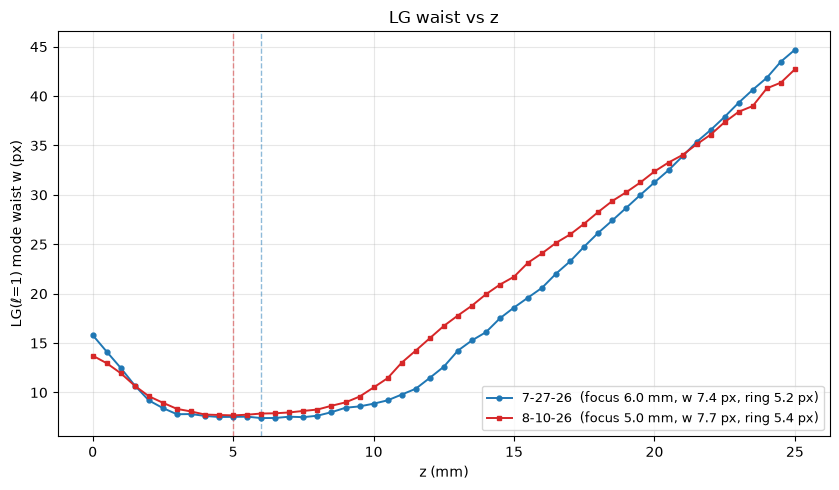

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for s in scans.values():
    c, m = STYLE[s.label]["color"], STYLE[s.label]["marker"]
    ax.plot(s.z_mm, s.lg_w_px, m + "-", ms=3.5, lw=1.4, color=c,
            label=f"{s.label}  (focus {s.focus_z_lg:.1f} mm, w {s.min_lg_w:.1f} px, "
                  f"ring {s.min_lg_w / np.sqrt(2):.1f} px)")
    ax.axvline(s.focus_z_lg, color=c, ls="--", lw=1, alpha=0.5)
ax.set_xlabel("z (mm)")
ax.set_ylabel("LG(ℓ=1) mode waist w (px)")
ax.set_title("LG waist vs z")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_ROOT / "focus_curve_lg.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · Clipping & on-axis intensity

Left: raw per-frame maximum vs z against the 10-bit clip level (1022); `7-27-26` rides the
ceiling across its focus region. Middle: number of pixels pinned at the clip level per frame —
directly how much of the peak is destroyed. Right: on-axis (central-column) counts vs z,
background-subtracted, showing the ~10× exposure gap.

peak on-axis brightness ratio 7-27-26 / 8-10-26 = 10.5x
7-27-26: raw frame max = 1022 cts | 20 of 51 frames saturated (max 193 px/frame)
8-10-26: raw frame max = 290 cts | 0 of 51 frames saturated (max 0 px/frame)


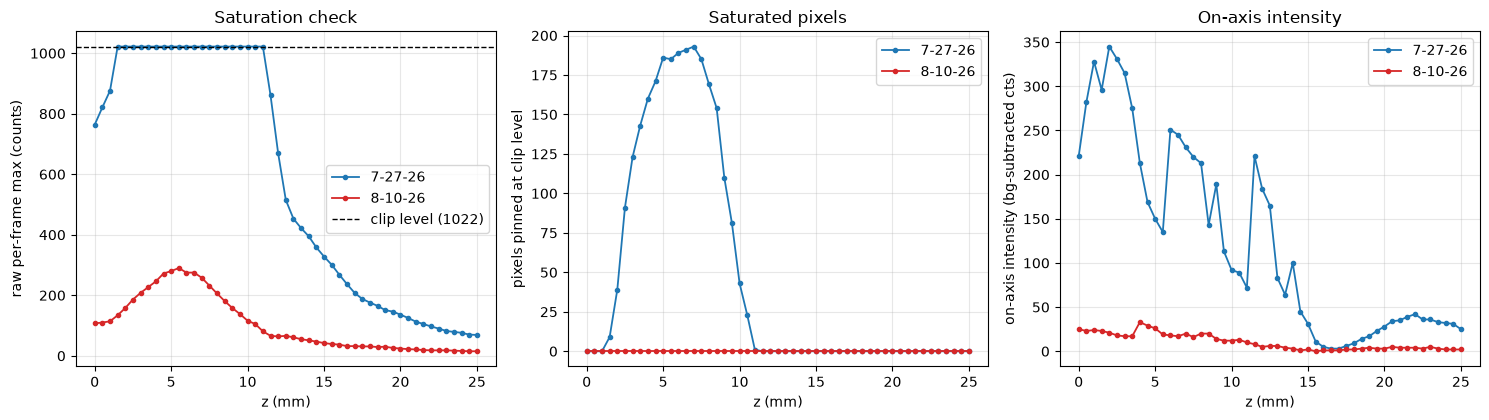

In [9]:
fig, (axL, axM, axR) = plt.subplots(1, 3, figsize=(15, 4.3))
for s in scans.values():
    c = COLOURS[s.label]
    axL.plot(s.z_mm, s.frame_max_raw, "o-", ms=3, lw=1.3, color=c, label=s.label)
    axM.plot(s.z_mm, s.n_saturated, "o-", ms=3, lw=1.3, color=c, label=s.label)
    axR.plot(s.z_mm, s.onaxis, "o-", ms=3, lw=1.3, color=c, label=s.label)

axL.axhline(SAT_LEVEL, color="k", ls="--", lw=1, label=f"clip level ({SAT_LEVEL})")
axL.set_xlabel("z (mm)"); axL.set_ylabel("raw per-frame max (counts)")
axL.set_title("Saturation check"); axL.legend(); axL.grid(alpha=0.3)

axM.set_xlabel("z (mm)"); axM.set_ylabel("pixels pinned at clip level")
axM.set_title("Saturated pixels"); axM.legend(); axM.grid(alpha=0.3)

axR.set_xlabel("z (mm)"); axR.set_ylabel("on-axis intensity (bg-subtracted cts)")
axR.set_title("On-axis intensity"); axR.legend(); axR.grid(alpha=0.3)

ratio = scans["7-27-26"].onaxis.max() / max(scans["8-10-26"].onaxis.max(), 1e-9)
print(f"peak on-axis brightness ratio 7-27-26 / 8-10-26 = {ratio:.1f}x")
for s in scans.values():
    nsat = (s.n_saturated > 0).sum()
    print(f"{s.label}: raw frame max = {s.frame_max_raw.max():.0f} cts | "
          f"{nsat} of {s.z_mm.size} frames saturated (max {int(s.n_saturated.max())} px/frame)")
fig.tight_layout()
fig.savefig(OUT_ROOT / "clipping_and_onaxis.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 · Centroid-drift diagnostic

Low exposure means fewer photons and a noisier centroid, which would corrupt the tracked slice.
Smooth, slowly-varying traces mean the tracking held up. Sharp excursions — especially near
focus — would warn that a width or waterfall feature is a tracking artefact, not the beam.

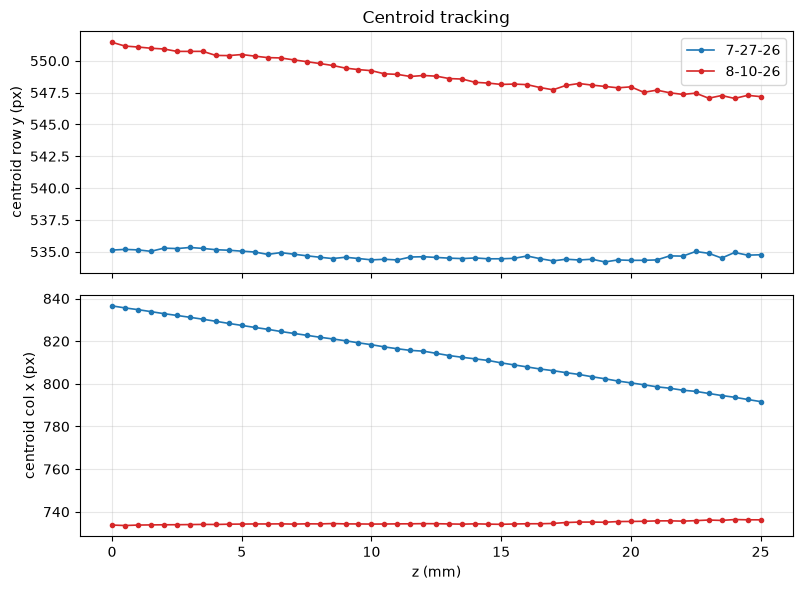

In [10]:
fig, (axy, axx) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for s in scans.values():
    axy.plot(s.z_mm, s.centroid_y, "o-", ms=3, lw=1.2, color=COLOURS[s.label], label=s.label)
    axx.plot(s.z_mm, s.centroid_x, "o-", ms=3, lw=1.2, color=COLOURS[s.label], label=s.label)
axy.set_ylabel("centroid row y (px)"); axy.set_title("Centroid tracking")
axy.legend(); axy.grid(alpha=0.3)
axx.set_ylabel("centroid col x (px)"); axx.set_xlabel("z (mm)"); axx.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_ROOT / "centroid_drift.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 · Summary table

One row per scan plus a **difference** row (8-10-26 − 7-27-26): focus z by each metric (measured
RMS, LG), the widths, brightest z, saturated frames, and centroid drift/step-std. Written to
`outputs/waterfall_l1_exposure_compare/summary.csv`.

In [11]:
rows = []
for s in scans.values():
    rows.append({
        "scan": s.label,
        "n_frames": s.z_mm.size,
        "focus_z_rms_mm": s.focus_z,
        "min_width_rms_px": s.min_width,
        "focus_z_lg_mm": s.focus_z_lg,
        "lg_waist_px": s.min_lg_w,
        "lg_rms_px": s.min_lg_rms,
        "lg_ring_radius_px": s.min_lg_w / np.sqrt(2),
        "rms_over_lg_rms": s.min_width / s.min_lg_rms,
        "brightest_z_mm": s.brightest_z,
        "saturated_frames": int((s.n_saturated > 0).sum()),
        "max_saturated_px": int(s.n_saturated.max()),
        "peak_onaxis_cts": float(s.onaxis.max()),
        "raw_frame_max_cts": float(s.frame_max_raw.max()),
        "row_drift_px": float(np.ptp(s.centroid_y)),
        "col_drift_px": float(np.ptp(s.centroid_x)),
        "row_step_std_px": float(np.diff(s.centroid_y).std()),
        "col_step_std_px": float(np.diff(s.centroid_x).std()),
        "inferred_positions": s.inferred_positions,
    })
summary = pd.DataFrame(rows).set_index("scan")

num = summary.select_dtypes("number")
diff = (num.loc["8-10-26"] - num.loc["7-27-26"]).to_frame().T
diff.index = ["diff (8-10-26 - 7-27-26)"]
summary = pd.concat([summary, diff])
summary = summary.round(2)

summary.to_csv(OUT_ROOT / "summary.csv")
print(f"saved -> {(OUT_ROOT / 'summary.csv').relative_to(REPO_ROOT)}")
with pd.option_context("display.max_columns", None, "display.width", 200):
    display(summary)

saved -> outputs\waterfall_l1_exposure_compare\summary.csv


,n_frames,focus_z_rms_mm,min_width_rms_px,focus_z_lg_mm,lg_waist_px,lg_rms_px,lg_ring_radius_px,rms_over_lg_rms,brightest_z_mm,saturated_frames,max_saturated_px,peak_onaxis_cts,raw_frame_max_cts,row_drift_px,col_drift_px,row_step_std_px,col_step_std_px,inferred_positions
7-27-26,51.0,2.0,16.61,6.0,7.41,6.41,5.24,2.59,2.5,20.0,193.0,345.0,1022.0,1.14,44.88,0.15,0.13,False
8-10-26,51.0,6.0,12.65,5.0,7.68,6.65,5.43,1.90,5.0,0.0,0.0,33.0,290.0,4.41,2.81,0.15,0.14,False
diff (8-10-26 - 7-27-26),0.0,4.0,-3.97,-1.0,0.27,0.24,0.19,-0.69,2.5,-20.0,-193.0,-312.0,-732.0,3.27,-42.07,0.00,0.01,NaN
